In [1]:
import pandas as pd

# 加载 TL 外推数据
tl_data_path = 'D:/creep rupture/TL/温度分类/重选特征/总目标TSdata600-1000CGAN+TL.xlsx'
tl_data = pd.read_excel(tl_data_path)

# 加载无 TL 外推数据
no_tl_data_path = 'D:/creep rupture/TL/温度分类/重选特征/消融实验总数据.xlsx'
no_tl_data = pd.read_excel(no_tl_data_path)

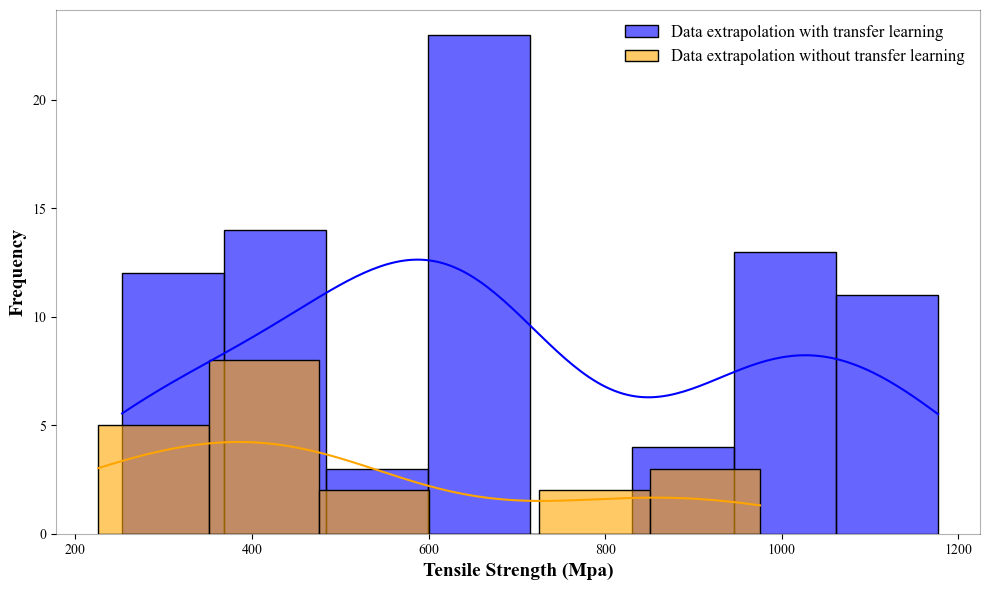

In [7]:

# 假设抗拉强度列名为 '抗拉强度'
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'Times New Roman'

# 创建图表
plt.figure(figsize=(10, 6))

# 绘制直方图
sns.histplot(tl_data['Tensile Strength(Mpa)'], 
             label='Data extrapolation with transfer learning', 
             kde=True, color='blue', alpha=0.6)
sns.histplot(no_tl_data['Tensile Strength(Mpa)'], 
             label='Data extrapolation without transfer learning', 
             kde=True, color='orange', alpha=0.6)

# 设置标题和标签
plt.xlabel('Tensile Strength (Mpa)', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
# 设置图例
plt.legend(fontsize=12, frameon=False)


# 设置边框透明度
for spine in plt.gca().spines.values():
    spine.set_alpha(0.3)
# 保存图形为PNG和PDF
plt.savefig('D:/creep rupture/TL/温度分类/重选特征/消融对比直方图.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('D:/creep rupture/TL/温度分类/重选特征/消融对比直方图.pdf', format='pdf', bbox_inches='tight')

# 显示图表
plt.tight_layout()
plt.show()

In [12]:
import numpy as np

# TL 外推数据的统计指标
tl_mean = np.mean(tl_data['Tensile Strength(Mpa)'])
tl_median = np.median(tl_data['Tensile Strength(Mpa)'])
tl_std = np.std(tl_data['Tensile Strength(Mpa)'])
tl_min = np.min(tl_data['Tensile Strength(Mpa)'])
tl_max = np.max(tl_data['Tensile Strength(Mpa)'])

# 无 TL 外推数据的统计指标
no_tl_mean = np.mean(no_tl_data['Tensile Strength(Mpa)'])
no_tl_median = np.median(no_tl_data['Tensile Strength(Mpa)'])
no_tl_std = np.std(no_tl_data['Tensile Strength(Mpa)'])
no_tl_min = np.min(no_tl_data['Tensile Strength(Mpa)'])
no_tl_max = np.max(no_tl_data['Tensile Strength(Mpa)'])

# 输出结果
print("TL 外推数据的统计指标：")
print(f"均值: {tl_mean}, 中位数: {tl_median}, 标准差: {tl_std}, 最小值: {tl_min}, 最大值: {tl_max}")

print("无 TL 外推数据的统计指标：")
print(f"均值: {no_tl_mean}, 中位数: {no_tl_median}, 标准差: {no_tl_std}, 最小值: {no_tl_min}, 最大值: {no_tl_max}")

TL 外推数据的统计指标：
均值: 692.27451171875, 中位数: 640.1223754882812, 标准差: 282.2010715424905, 最小值: 253.0, 最大值: 1177.0
无 TL 外推数据的统计指标：
均值: 496.0869171142578, 中位数: 440.3623962402344, 标准差: 239.06172295088643, 最小值: 225.9337463378906, 最大值: 975.3776245117188


In [13]:
from scipy.stats import ttest_ind

# 假设检验
t_statistic, p_value = ttest_ind(tl_data['Tensile Strength(Mpa)'], no_tl_data['Tensile Strength(Mpa)'])

# 输出结果
print(f"t 统计量: {t_statistic}, p 值: {p_value}")

if p_value < 0.05:
    print("TL 外推数据与无 TL 外推数据的抗拉强度存在显著差异（p < 0.05）。")
else:
    print("TL 外推数据与无 TL 外推数据的抗拉强度无显著差异（p >= 0.05）。")

t 统计量: 2.8340585004806633, p 值: 0.005581549859757044
TL 外推数据与无 TL 外推数据的抗拉强度存在显著差异（p < 0.05）。


AttributeError: 'NoneType' object has no attribute 'set_label'

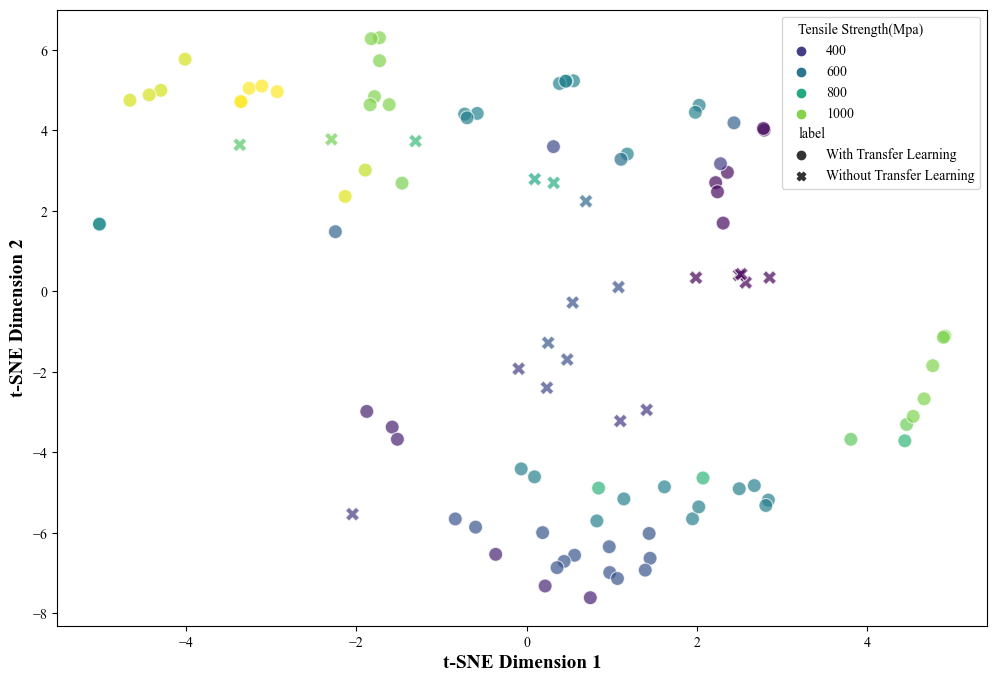

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据
tl_data_path = 'D:/creep rupture/TL/温度分类/重选特征/总目标TSdata600-1000CGAN+TL.xlsx'
tl_data = pd.read_excel(tl_data_path)
tl_data['label'] = 'With Transfer Learning'  # 添加标签

no_tl_data_path = 'D:/creep rupture/TL/温度分类/重选特征/消融实验总数据.xlsx'
no_tl_data = pd.read_excel(no_tl_data_path)
no_tl_data['label'] = 'Without Transfer Learning'  # 添加标签

# 合并数据
combined_data = pd.concat([tl_data, no_tl_data], axis=0)

# 移除标签列和目标列，保留特征列
features = combined_data.drop(columns=['label', 'Tensile Strength(Mpa)'])

# 标准化特征数据
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 应用 t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)  # 降维到 2D
tsne_results = tsne.fit_transform(scaled_features)

# 将结果添加到数据中
combined_data['tsne_1'] = tsne_results[:, 0]
combined_data['tsne_2'] = tsne_results[:, 1]

# 设置全局字体为 Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# 创建 t-SNE 图
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='Tensile Strength(Mpa)',  # 用颜色表示目标变量
    style='label',  # 用形状区分有 TL 和无 TL
    palette='viridis',  # 颜色映射
    data=combined_data,
    alpha=0.7,
    s=100  # 点的大小
)

# 设置标题和标签

plt.xlabel('t-SNE Dimension 1', fontsize=14, fontweight='bold')
plt.ylabel('t-SNE Dimension 2', fontsize=14, fontweight='bold')

# 获取当前图形的轴对象
ax = plt.gca()

# 获取颜色条（colorbar）
cbar = scatter.collections[0].colorbar
cbar.set_label('Tensile Strength (Mpa)', labelpad=15)

# 创建自定义图例项
handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    handles[0],  # 第一个颜色项
    handles[-1],  # 最后一个颜色项
    handles[-2]  # 形状项
]

custom_labels = [
    'Color indicates higher tensile strength',
    'Color indicates lower tensile strength',
    'Shape indicates With Transfer Learning and Without Transfer learning'
]

# 添加自定义图例
ax.legend(custom_handles, custom_labels, title='Legend', loc='upper right', fontsize=12, title_fontsize=14)

# 设置网格线
plt.grid(True, linestyle='--', alpha=0.6)

# 设置边框透明度
for spine in ax.spines.values():
    spine.set_alpha(0.3)

# 保存图形为PNG和PDF
plt.savefig('D:/creep rupture/TL/温度分类/重选特征/消融对比t_sne.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('D:/creep rupture/TL/温度分类/重选特征/消融对比t_sne.pdf', format='pdf', bbox_inches='tight')

# 显示图表
plt.tight_layout()
plt.show()

C:\Users\zangd\AppData\Local\Temp\ipykernel_24872\628349883.py:57: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  cbar = plt.colorbar(scatter.legend_.legendHandles[0])


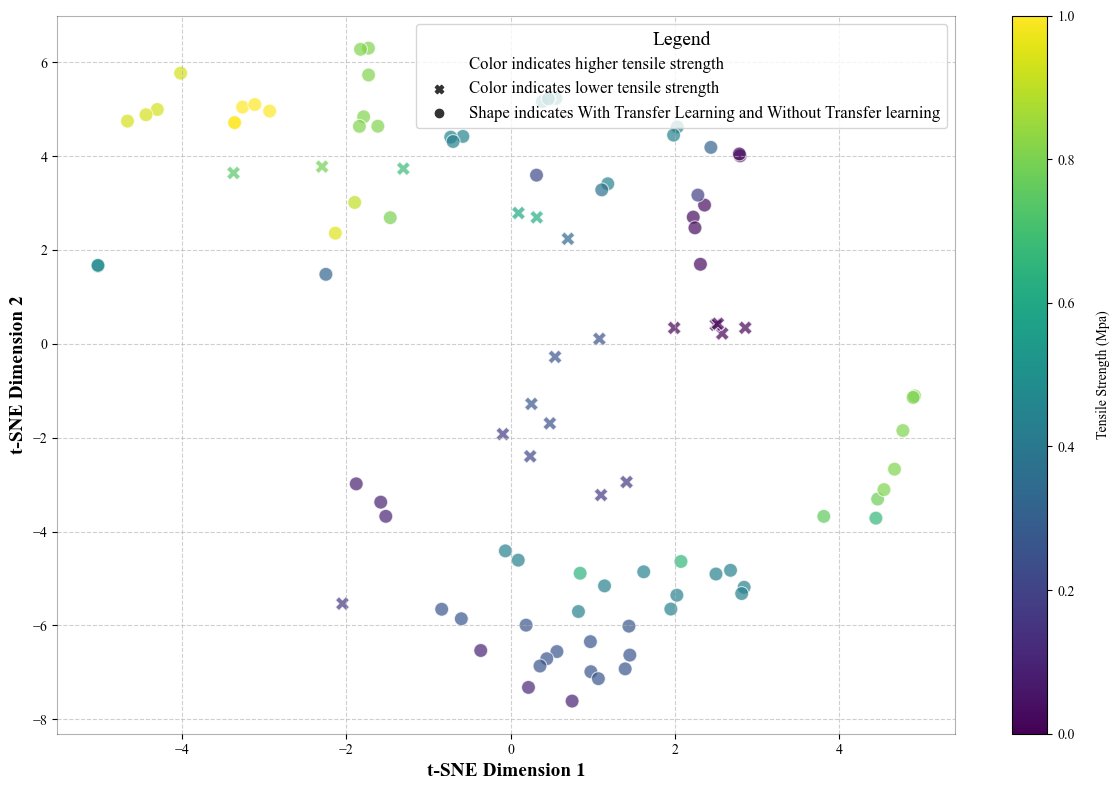

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据
tl_data_path = 'D:/creep rupture/TL/温度分类/重选特征/总目标TSdata600-1000CGAN+TL.xlsx'
tl_data = pd.read_excel(tl_data_path)
tl_data['label'] = 'With Transfer Learning'  # 添加标签

no_tl_data_path = 'D:/creep rupture/TL/温度分类/重选特征/消融实验总数据.xlsx'
no_tl_data = pd.read_excel(no_tl_data_path)
no_tl_data['label'] = 'Without Transfer Learning'  # 添加标签

# 合并数据
combined_data = pd.concat([tl_data, no_tl_data], axis=0)

# 移除标签列和目标列，保留特征列
features = combined_data.drop(columns=['label', 'Tensile Strength(Mpa)'])

# 标准化特征数据
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 应用 t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)  # 降维到 2D
tsne_results = tsne.fit_transform(scaled_features)

# 将结果添加到数据中
combined_data['tsne_1'] = tsne_results[:, 0]
combined_data['tsne_2'] = tsne_results[:, 1]

# 设置全局字体为 Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# 创建 t-SNE 图
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='Tensile Strength(Mpa)',  # 用颜色表示目标变量
    style='label',  # 用形状区分有 TL 和无 TL
    palette='viridis',  # 颜色映射
    data=combined_data,
    alpha=0.7,
    s=100  # 点的大小
)

# 设置标题和标签
plt.xlabel('t-SNE Dimension 1', fontsize=14, fontweight='bold')
plt.ylabel('t-SNE Dimension 2', fontsize=14, fontweight='bold')

# 获取当前图形的轴对象
ax = plt.gca()

# 获取颜色条（colorbar）
cbar = plt.colorbar(scatter.legend_.legendHandles[0])
cbar.set_label('Tensile Strength (Mpa)', labelpad=15)

# 创建自定义图例项
handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    handles[0],  # 第一个颜色项
    handles[-1],  # 最后一个颜色项
    handles[-2]  # 形状项
]

custom_labels = [
    'Color indicates higher tensile strength',
    'Color indicates lower tensile strength',
    'Shape indicates With Transfer Learning and Without Transfer learning'
]

# 添加自定义图例
ax.legend(custom_handles, custom_labels, title='Legend', loc='upper right', fontsize=12, title_fontsize=14)

# 设置网格线
plt.grid(True, linestyle='--', alpha=0.6)

# 设置边框透明度
for spine in ax.spines.values():
    spine.set_alpha(0.3)

# 保存图形为PNG和PDF
plt.savefig('D:/creep rupture/TL/温度分类/重选特征/消融对比t_sne.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('D:/creep rupture/TL/温度分类/重选特征/消融对比t_sne.pdf', format='pdf', bbox_inches='tight')

# 显示图表
plt.tight_layout()
plt.show()

C:\Users\zangd\AppData\Local\Temp\ipykernel_24872\1810319104.py:57: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  cbar = plt.colorbar(scatter.legend_.legendHandles[0])


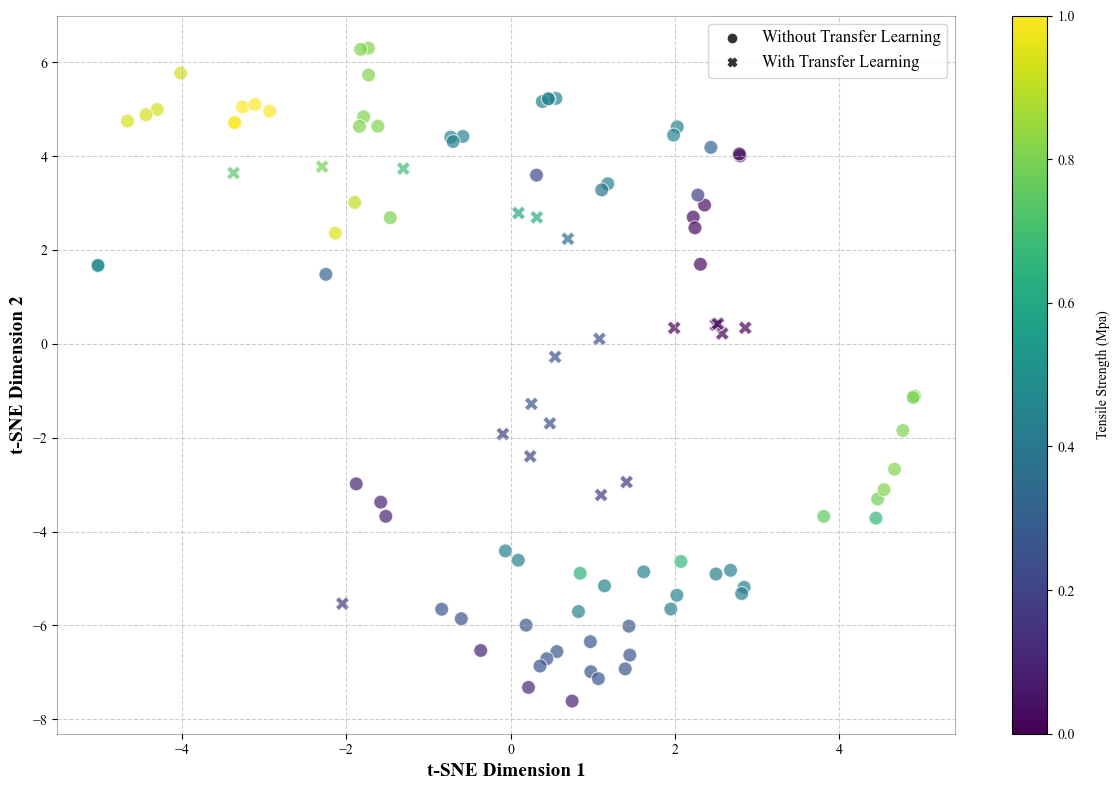

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据
tl_data_path = 'D:/creep rupture/TL/温度分类/重选特征/总目标TSdata600-1000CGAN+TL.xlsx'
tl_data = pd.read_excel(tl_data_path)
tl_data['label'] = 'With Transfer Learning'  # 添加标签

no_tl_data_path = 'D:/creep rupture/TL/温度分类/重选特征/消融实验总数据.xlsx'
no_tl_data = pd.read_excel(no_tl_data_path)
no_tl_data['label'] = 'Without Transfer Learning'  # 添加标签

# 合并数据
combined_data = pd.concat([tl_data, no_tl_data], axis=0)

# 移除标签列和目标列，保留特征列
features = combined_data.drop(columns=['label', 'Tensile Strength(Mpa)'])

# 标准化特征数据
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 应用 t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)  # 降维到 2D
tsne_results = tsne.fit_transform(scaled_features)

# 将结果添加到数据中
combined_data['tsne_1'] = tsne_results[:, 0]
combined_data['tsne_2'] = tsne_results[:, 1]

# 设置全局字体为 Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# 创建 t-SNE 图
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='Tensile Strength(Mpa)',  # 用颜色表示目标变量
    style='label',  # 用形状区分有 TL 和无 TL
    palette='viridis',  # 颜色映射
    data=combined_data,
    alpha=0.7,
    s=100  # 点的大小
)

# 设置标题和标签
plt.xlabel('t-SNE Dimension 1', fontsize=14, fontweight='bold')
plt.ylabel('t-SNE Dimension 2', fontsize=14, fontweight='bold')

# 获取当前图形的轴对象
ax = plt.gca()

# 获取颜色条（colorbar）
cbar = plt.colorbar(scatter.legend_.legendHandles[0])
cbar.set_label('Tensile Strength (Mpa)', labelpad=15)

# 创建自定义图例项
handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    handles[-2],  # × 形状项
    handles[-1]   # · 形状项
]

custom_labels = [
    'Without Transfer Learning',
    'With Transfer Learning'
]

# 添加自定义图例
ax.legend(custom_handles, custom_labels, title=None, loc='upper right', fontsize=12)

# 设置网格线
plt.grid(True, linestyle='--', alpha=0.6)

# 设置边框透明度
for spine in ax.spines.values():
    spine.set_alpha(0.3)

# 保存图形为PNG和PDF
plt.savefig('D:/creep rupture/TL/温度分类/重选特征/消融对比t_sne.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('D:/creep rupture/TL/温度分类/重选特征/消融对比t_sne.pdf', format='pdf', bbox_inches='tight')

# 显示图表
plt.tight_layout()
plt.show()